0 - Bibliotecas e carga de dados

In [1]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)


# Carregando arquivos Parquet

DADOS_DIR = Path("../dados/consolidados")

#print(DADOS_DIR.resolve())
#print(list(DADOS_DIR.iterdir()))

mshl = pd.read_parquet(DADOS_DIR / "MSHL_consolidado.parquet")
cnes_lt = pd.read_parquet(DADOS_DIR / "LT_consolidado.parquet")
sih_rd = pd.read_parquet(DADOS_DIR / "RD_consolidado.parquet")

#Verificar se carregou corretamente
print("MSHL:", mshl.shape)
print("CNES-LT:", cnes_lt.shape)
print("SIH-RD:", sih_rd.shape)

MSHL: (2673, 9)
CNES-LT: (13079, 8)
SIH-RD: (696841, 20)


1. MSHL - Estabelecimentos

In [2]:
mshl.describe()

,LEITOS_EXISTENTES,LEITOS_SUS
count,"2,673.00","2,673.00"
mean,134.21,85.98
std,189.91,179.92
min,1.00,0.00
25%,22.00,0.00
50%,67.00,0.00
75%,170.00,77.00
max,"1,104.00","1,072.00"


In [3]:
print("Leitos existentes:", mshl["LEITOS_EXISTENTES"].sum())
print("Leitos SUS:", mshl["LEITOS_SUS"].sum())

Leitos existentes: 358734
Leitos SUS: 229834


Leitos por estabelecimento

In [4]:
leitos_estabelecimento = (
    mshl.groupby(
        ["CNES", "NOME_ESTABELECIMENTO"]
    )
    .agg(
        leitos_existentes=("LEITOS_EXISTENTES", "sum"),
        leitos_sus=("LEITOS_SUS", "sum")
    )
    .reset_index()
    .sort_values("leitos_sus", ascending=False)
)

leitos_estabelecimento.head(20)

,CNES,NOME_ESTABELECIMENTO,leitos_existentes,leitos_sus
3,0000434,IMIP,33736,33524
8,0000655,HOSPITAL DA RESTAURACAO,26720,26304
2,0000426,HOSPITAL OTAVIO DE FREITAS,18879,18496
4,0000477,HOSPITAL OSWALDO CRUZ,14812,14250
46,2802783,HOSPITAL GETULIO VARGAS,13583,13583
1,0000418,HOSPITAL AGAMENON MAGALHAES,12589,12589
36,2427427,HOSPITAL BARAO DE LUCENA,13043,12523
0,0000396,HOSPITAL DAS CLINICAS,9993,9733
7,0000582,HOSPITAL DE CANCER DE PERNAMBUCO,8226,8226
62,3983730,PROCAPE,8102,8092


Evolução dos leitos

In [5]:
leitos_competencia = (
    mshl.groupby("COMPETEN")
    .agg(
        estabelecimentos=("CNES", "nunique"),
        leitos_existentes=("LEITOS_EXISTENTES", "sum"),
        leitos_sus=("LEITOS_SUS", "sum")
    )
    .reset_index()
    .sort_values("COMPETEN")
)

leitos_competencia

,COMPETEN,estabelecimentos,leitos_existentes,leitos_sus
0,202401,81,11133,7199
1,202402,81,11124,7190
2,202403,81,11148,7190
3,202404,81,11148,7190
4,202405,81,11176,7232
5,202406,83,11197,7279
6,202407,83,11199,7287
7,202408,83,11156,7286
8,202409,83,11144,7267
9,202410,82,11133,7254


In [ ]:
Grafico

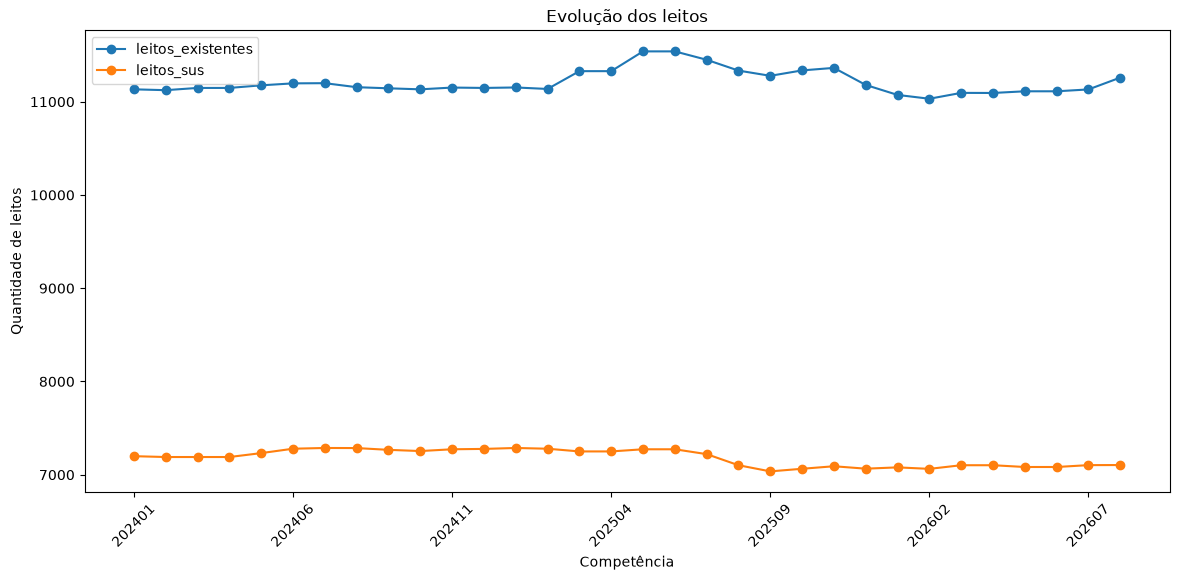

In [6]:
leitos_competencia.plot(
    x="COMPETEN",
    y=["leitos_existentes", "leitos_sus"],
    figsize=(14, 6),
    marker="o"
)

plt.title("Evolução dos leitos")
plt.xlabel("Competência")
plt.ylabel("Quantidade de leitos")
plt.xticks(rotation=45)
plt.show()

2. CNES-LT - Tipos de leitos

In [7]:
cnes_lt["TP_LEITO"].value_counts().head(30)

TP_LEITO
1    8035
2    5044
Name: count, dtype: int64[pyarrow]

In [8]:
cnes_lt["CODLEITO"].nunique()

30

Leitos por tipo

In [9]:
leitos_tipo = (
    cnes_lt.groupby("TP_LEITO")
    .agg(
        estabelecimentos=("CNES", "nunique"),
        leitos_existentes=("QT_EXIST", "sum"),
        leitos_sus=("QT_SUS", "sum")
    )
    .reset_index()
    .sort_values("leitos_sus", ascending=False)
)

leitos_tipo.head(30)

,TP_LEITO,estabelecimentos,leitos_existentes,leitos_sus
1,2,58,115228,67717
0,1,74,97474,66547


Evolução dos leitos por tipo

In [ ]:
evolucao_tipo = (
    cnes_lt.groupby(["COMPETEN", "TP_LEITO"])
    .agg(
        leitos_existentes=("QT_EXIST", "sum"),
        leitos_sus=("QT_SUS", "sum")
    )
    .reset_index()
)

#evolucao_tipo.head(10)

,COMPETEN,TP_LEITO,leitos_existentes,leitos_sus
0,202401,1,2948,1979
1,202401,2,3865,2366
2,202402,1,2948,1979
3,202402,2,3865,2366
4,202403,1,3026,2039
5,202403,2,3811,2306
6,202404,1,3026,2039
7,202404,2,3811,2306
8,202405,1,3038,2081
9,202405,2,3803,2298


In [15]:
top_tipos = (
    cnes_lt.groupby("TP_LEITO")["QT_SUS"]
    .sum()
    .nlargest(10)
    .index
)

evolucao_top = evolucao_tipo[
    evolucao_tipo["TP_LEITO"].isin(top_tipos)
]

In [ ]:
Comparação MSHL × CNES-LT

In [18]:
#As duas fontes de leitos estão contando a mesma coisa?

mshl_cnes = (
    mshl.groupby(["COMPETEN", "CNES"])
    .agg(
        leitos_mshl=("LEITOS_SUS", "sum")
    )
    .reset_index()
)

lt_cnes = (
    cnes_lt.groupby(["COMPETEN", "CNES"])
    .agg(
        leitos_cnes_lt=("QT_SUS", "sum")
    )
    .reset_index()
)

comparacao_leitos = mshl_cnes.merge(
    lt_cnes,
    on=["COMPETEN", "CNES"],
    how="outer"
)

comparacao_leitos[
    ["leitos_mshl", "leitos_cnes_lt"]
] = comparacao_leitos[
    ["leitos_mshl", "leitos_cnes_lt"]
].fillna(0)

# Diferença
comparacao_leitos["diferenca"] = (
    comparacao_leitos["leitos_mshl"]
    - comparacao_leitos["leitos_cnes_lt"]
)

comparacao_leitos["diferenca"].describe()

count   2,948.00
mean       32.42
std        85.71
min        -3.00
25%         0.00
50%         0.00
75%        40.00
max     1,046.00
Name: diferenca, dtype: Float64

estabelecimentos com maiores diferenças

In [20]:
comparacao_leitos.reindex(
    comparacao_leitos["diferenca"].abs()
    .sort_values(ascending=False)
    .index
).head(10)

,COMPETEN,CNES,leitos_mshl,leitos_cnes_lt,diferenca
2863,202608,0000434,1046,0,1046
2868,202608,0000655,822,0,822
2018,202511,0000434,1072,396,676
1925,202510,0000434,1072,396,676
273,202404,0000434,1046,396,650
1553,202506,0000434,1046,396,650
93,202402,0000434,1046,396,650
1460,202505,0000434,1046,396,650
729,202409,0000434,1046,396,650
1646,202507,0000434,1046,396,650
